# 2b. Grid-Search Pipeline Validation

**Purpose**: Validate that the grid-search CV pipeline runs correctly
and produces sensible, reproducible results before running at scale.

**Checks**:
1. Pipeline runs without error on real data
2. Errors are finite and positive
3. Model ranking is consistent across seeds
4. Best-fit parameters are stable across seeds

For comparison against the legacy pipeline, see notebook 2d.

In [1]:
%matplotlib inline
from shared_setup import *

import time

from analysis.grid_search import grid_search_cv, COARSE_GRID, DEFAULT_GRID

## 1. Configuration

In [2]:
TARGET_ANIMAL = 'SS01'
VALIDATION_SEEDS = [1, 2, 3]
USE_COARSE = True   # True for quick validation
N_FOLDS = 2
BURN_IN = 1000

## 2. Load Data

In [3]:
experiment, load_info = load_data()

if TARGET_ANIMAL not in experiment.animal_ids:
    TARGET_ANIMAL = experiment.animal_ids[0]
    print(f'TARGET_ANIMAL not found, using {TARGET_ANIMAL}')

animal = experiment.get_animal(TARGET_ANIMAL)
sessions = animal.get_sessions(stage=STAGE)

# Use last half as expert proxy
expert_sessions = sessions[len(sessions)//2:]
print(f'{TARGET_ANIMAL}: {len(expert_sessions)} expert sessions, '
      f'{sum(s.n_trials for s in expert_sessions)} total trials')

Loaded 12 animals, 433 total sessions
Loaded 12 animals, 433 sessions from CSV
SS01: 25 expert sessions, 12707 total trials


## 3. Run Grid-Search CV

In [4]:
grids = COARSE_GRID if USE_COARSE else DEFAULT_GRID

results = {}  # (model_type, seed) -> result dict

for seed in VALIDATION_SEEDS:
    for model_type in ['BE', 'SC']:
        key = (model_type, seed)
        print(f'{model_type} seed={seed}... ', end='', flush=True)
        t0 = time.time()

        try:
            result = grid_search_cv(
                expert_sessions, model_type, grids[model_type],
                n_folds=N_FOLDS, seed=seed, burn_in=BURN_IN,
            )
            elapsed = time.time() - t0
            results[key] = result
            print(f'err={result["avg_test_error"]:.4f} ({elapsed:.1f}s)')
        except Exception as e:
            print(f'FAILED: {e}')
            import traceback; traceback.print_exc()
            results[key] = None

n_ok = sum(v is not None for v in results.values())
print(f'\n{n_ok}/{len(results)} runs succeeded')

BE seed=1... err=0.0143 (126.0s)
SC seed=1... err=0.0078 (180.1s)
BE seed=2... err=0.0117 (121.0s)
SC seed=2... err=0.0146 (179.0s)
BE seed=3... err=0.0107 (114.1s)
SC seed=3... err=0.0084 (177.2s)

6/6 runs succeeded


## 4. Sanity Checks

Are the errors finite, positive, and in a reasonable range?

In [5]:
rows = []
for seed in VALIDATION_SEEDS:
    for model_type in ['BE', 'SC']:
        key = (model_type, seed)
        r = results.get(key)
        if r is None:
            continue
        rows.append({
            'model': model_type, 'seed': seed,
            'avg_test_error': r['avg_test_error'],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format='%.4f'))

print('\n=== SANITY CHECKS ===')
for model_type in ['BE', 'SC']:
    sub = df[df['model'] == model_type]
    errs = sub['avg_test_error'].values
    print(f'\n{model_type}:')
    print(f'  Range: [{errs.min():.4f}, {errs.max():.4f}]')
    print(f'  Mean ± std: {errs.mean():.4f} ± {errs.std():.4f}')
    if errs.mean() > 0:
        print(f'  CV across seeds: {errs.std() / errs.mean():.2%}')
    if np.any(np.isnan(errs)):
        print('  ⚠ NaN errors detected!')
    if np.any(errs <= 0):
        print('  ⚠ Non-positive errors detected!')

model  seed  avg_test_error
   BE     1          0.0143
   SC     1          0.0078
   BE     2          0.0117
   SC     2          0.0146
   BE     3          0.0107
   SC     3          0.0084

=== SANITY CHECKS ===

BE:
  Range: [0.0107, 0.0143]
  Mean ± std: 0.0122 ± 0.0015
  CV across seeds: 12.35%

SC:
  Range: [0.0078, 0.0146]
  Mean ± std: 0.0103 ± 0.0031
  CV across seeds: 29.77%


## 5. Model Ranking Consistency

Does the same model win across all seeds?

In [6]:
winners = []
for seed in VALIDATION_SEEDS:
    be = results.get(('BE', seed))
    sc = results.get(('SC', seed))
    if be is None or sc is None:
        continue
    winner = 'BE' if be['avg_test_error'] < sc['avg_test_error'] else 'SC'
    delta = abs(be['avg_test_error'] - sc['avg_test_error'])
    winners.append(winner)
    print(f'Seed {seed}: {winner} wins (BE={be["avg_test_error"]:.4f}, '
          f'SC={sc["avg_test_error"]:.4f}, Δ={delta:.4f})')

if winners:
    consistent = len(set(winners)) == 1
    print(f'\nConsistent: {"YES" if consistent else "NO — rankings differ across seeds"}')
    if consistent:
        print(f'Winner: {winners[0]}')

Seed 1: SC wins (BE=0.0143, SC=0.0078, Δ=0.0065)
Seed 2: BE wins (BE=0.0117, SC=0.0146, Δ=0.0029)
Seed 3: SC wins (BE=0.0107, SC=0.0084, Δ=0.0023)

Consistent: NO — rankings differ across seeds


## 6. Parameter Stability

Are best-fit parameters in a similar region across seeds?

In [7]:
for model_type in ['BE', 'SC']:
    print(f'\n=== {model_type} ===')
    param_dicts = []
    for seed in VALIDATION_SEEDS:
        r = results.get((model_type, seed))
        if r is None:
            continue
        param_dicts.append(r['best_params_single'])

    if not param_dicts:
        print('  No results')
        continue

    param_df = pd.DataFrame(param_dicts)
    print(param_df.to_string(index=False, float_format='%.3f'))
    print()
    for col in param_df.columns:
        vals = param_df[col].values
        cv = vals.std() / vals.mean() if vals.mean() != 0 else np.nan
        print(f'  {col:>15s}: {vals.mean():.3f} ± {vals.std():.3f} (CV={cv:.1%})')


=== BE ===
 sigma_percep  A_repulsion  eta_learning  eta_relax
        0.050        0.000         0.214      0.050
        0.217        0.000         0.329      0.400
        0.133        0.000         0.329      0.400

     sigma_percep: 0.133 ± 0.068 (CV=51.0%)
      A_repulsion: 0.000 ± 0.000 (CV=nan%)
     eta_learning: 0.290 ± 0.054 (CV=18.5%)
        eta_relax: 0.283 ± 0.165 (CV=58.2%)

=== SC ===
 sigma_percep  A_repulsion  gamma  sigma_update
        0.300        0.000  0.614         1.000
        0.217        0.250  0.486         1.000
        0.300        0.250  0.614         1.000

     sigma_percep: 0.272 ± 0.039 (CV=14.4%)
      A_repulsion: 0.167 ± 0.118 (CV=70.7%)
            gamma: 0.571 ± 0.061 (CV=10.6%)
     sigma_update: 1.000 ± 0.000 (CV=0.0%)


## 7. Error Distribution

Quick visual of error spread across seeds.

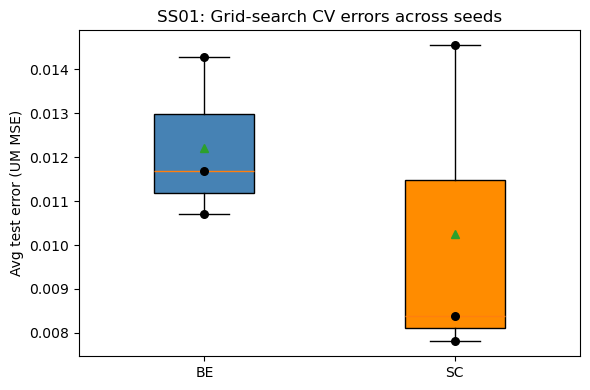

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

be_errs = [results[('BE', s)]['avg_test_error']
           for s in VALIDATION_SEEDS if results.get(('BE', s))]
sc_errs = [results[('SC', s)]['avg_test_error']
           for s in VALIDATION_SEEDS if results.get(('SC', s))]

positions = [1, 2]
bp = ax.boxplot([be_errs, sc_errs], positions=positions, widths=0.4,
                patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')
for i, errs in enumerate([be_errs, sc_errs]):
    ax.scatter([positions[i]] * len(errs), errs, color='black', s=30, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(['BE', 'SC'])
ax.set_ylabel('Avg test error (UM MSE)')
ax.set_title(f'{TARGET_ANIMAL}: Grid-search CV errors across seeds')
plt.tight_layout()
plt.show()

## 8. Conclusion

**Pass criteria**:
- All runs succeed (no crashes)
- Errors are finite, positive
- Same model wins across all seeds
- Parameter CV across seeds < 50%

If this passes, the pipeline is ready for full-scale cluster runs.
For legacy comparison, see notebook 2d.